<a href="https://colab.research.google.com/github/moshuhuang/RouteGuard-last-mile-address-risk/blob/main/03_business_impact_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Business Impact Simulation

This notebook translates model risk scores into operational recommendations.  
We simulate a pre-dispatch review workflow: by prioritizing the highest-risk parcels,  
operations can intercept bad addresses before dispatch with minimal review overhead.

**Final Model:** XGBoost (Structured Features + Text Embeddings)  
**Test Set:** 4,500 parcels | 900 risky (20% risk rate)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open('/content/drive/MyDrive/Git Projects/model_outputs.pkl', 'rb') as f:
    outputs = pickle.load(f)

y_test = outputs['y_test']
y_prob_test = outputs['y_prob_test']

df_test = pd.DataFrame({'y_true': y_test, 'y_prob': y_prob_test})
df_test = df_test.sort_values('y_prob', ascending=False).reset_index(drop=True)

print(f"Loaded. Test set: {len(df_test)} parcels, Risky: {df_test['y_true'].sum()}")

Mounted at /content/drive
Loaded. Test set: 4500 parcels, Risky: 900


## Review Rate Simulation

At different inspection thresholds, how many risky addresses can we catch?

In [3]:
review_rates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
total_parcels = len(df_test)
total_risky = df_test['y_true'].sum()

results = []
for rate in review_rates:
    n_review = int(total_parcels * rate)
    top_n = df_test.head(n_review)
    caught = top_n['y_true'].sum()
    results.append({
        'Review Rate': f"{rate:.0%}",
        'Parcels Reviewed': n_review,
        'Risky Caught': int(caught),
        'Recall': f"{caught/total_risky:.1%}",
        'Precision': f"{caught/n_review:.1%}"
    })

df_results = pd.DataFrame(results)
print("=== Pre-Dispatch Review Simulation ===")
print(df_results.to_string(index=False))

=== Pre-Dispatch Review Simulation ===
Review Rate  Parcels Reviewed  Risky Caught Recall Precision
         5%               225           225  25.0%    100.0%
        10%               450           433  48.1%     96.2%
        15%               675           479  53.2%     71.0%
        20%               900           512  56.9%     56.9%
        25%              1125           553  61.4%     49.2%
        30%              1350           585  65.0%     43.3%


## Recall vs Precision Trade-off

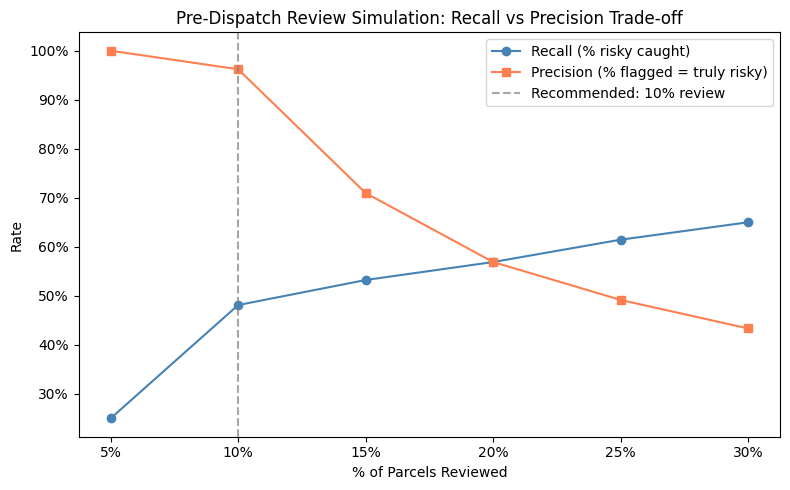

In [4]:
rates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
recalls = [df_test.head(int(total_parcels*r))['y_true'].sum()/total_risky for r in rates]
precisions = [df_test.head(int(total_parcels*r))['y_true'].sum()/int(total_parcels*r) for r in rates]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rates, recalls, marker='o', label='Recall (% risky caught)', color='steelblue')
ax.plot(rates, precisions, marker='s', label='Precision (% flagged = truly risky)', color='coral')
ax.axvline(x=0.10, color='gray', linestyle='--', alpha=0.7, label='Recommended: 10% review')
ax.set_xlabel('% of Parcels Reviewed')
ax.set_ylabel('Rate')
ax.set_title('Pre-Dispatch Review Simulation: Recall vs Precision Trade-off')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Git Projects/review_simulation.png', dpi=150)
plt.show()

## Business Impact at Scale

Extrapolating to a 50K daily parcel operation.

In [5]:
daily_parcels = 50000
daily_risky_rate = 0.20

print("=== Business Impact at Scale (50K daily parcels) ===\n")
for rate, recall in zip([0.05, 0.10, 0.15], [0.25, 0.48, 0.53]):
    n_review = int(daily_parcels * rate)
    caught = int(daily_parcels * daily_risky_rate * recall)
    print(f"Review top {rate:.0%} → {n_review:,} parcels reviewed/day → ~{caught:,} risky addresses intercepted")

print("\nRecommended: 10% review rate")
print("→ 5,000 parcels reviewed/day")
print("→ ~4,800 risky addresses intercepted before dispatch")
print("→ 96% Precision — minimal wasted review effort")

=== Business Impact at Scale (50K daily parcels) ===

Review top 5% → 2,500 parcels reviewed/day → ~2,500 risky addresses intercepted
Review top 10% → 5,000 parcels reviewed/day → ~4,800 risky addresses intercepted
Review top 15% → 7,500 parcels reviewed/day → ~5,300 risky addresses intercepted

Recommended: 10% review rate
→ 5,000 parcels reviewed/day
→ ~4,800 risky addresses intercepted before dispatch
→ 96% Precision — minimal wasted review effort
